# Sentiment Analysis of Movie Reviews 

Dataset: `IMDB Dataset.csv` 
Goal: Train a sentiment classifier that uses **embeddings** and handles **negation** .

> Important: We avoid aggressive cleaning (like stopword removal) because it can remove negation words like **not**, **never**, **no**.


## 1. Introduction

Sentiment Analysis is a core task in Natural Language Processing (NLP) that focuses on identifying the emotional tone expressed in textual data. In this project, we analyze movie reviews and build a machine learning model to classify sentiments as positive or negative.

## 2. Objectives

- Understand and explore a real-world sentiment dataset
- Apply NLP preprocessing techniques
- Use sentence embeddings for feature extraction
- Train and evaluate a machine learning classifier
- Demonstrate a complete sentiment analysis pipeline

## 3. Dataset Description

The IMDB Movie Reviews dataset is used in this project. Each record contains:

- **review**: Text of the movie review
- **sentiment**: Label indicating positive or negative sentiment

This dataset is widely used for academic sentiment analysis tasks.

## 4. Importing Required Libraries

In [1]:
# !pip install -U pandas numpy scikit-learn matplotlib joblib sentence-transformers

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## 5. Loading the Dataset

The dataset is loaded using pandas. Only relevant columns are retained.

In [3]:

df = pd.read_csv("IMDB Dataset.csv")  
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 6. Exploratory Data Analysis (EDA)

Basic inspection of the dataset to understand its structure and cleanliness.


#### Key checks include:
- dataset shape & missing values  
- label balance (positive vs negative)  
- review length (characters & words)  
- most common words in each sentiment (quick intuition)  


#### EDA helps ensure:
- The dataset is clean
- No missing values exist
- Sentiment classes are reasonably balanced

This step builds confidence before applying machine learning models.

Shape: (50000, 2)

Columns: ['review', 'sentiment']

Missing values per column:
review       0
sentiment    0
dtype: int64

Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


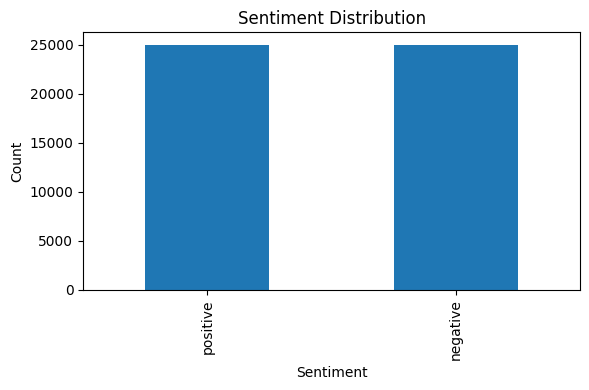


Review length (characters) summary:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: char_len, dtype: float64

Review length (words) summary:
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_len, dtype: float64


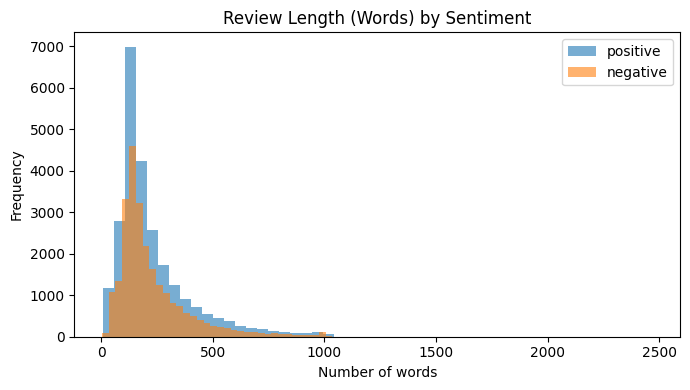

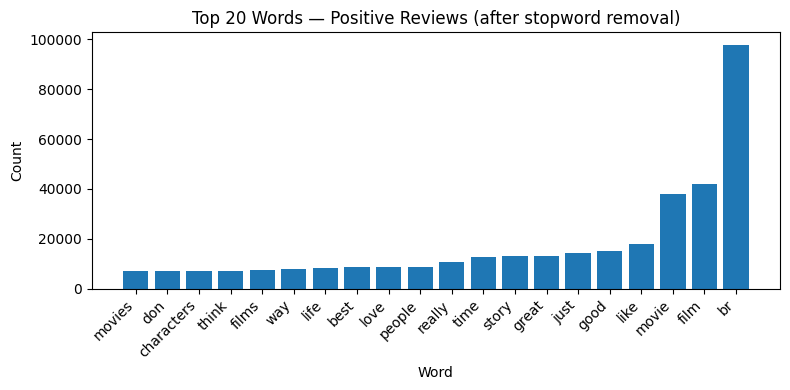

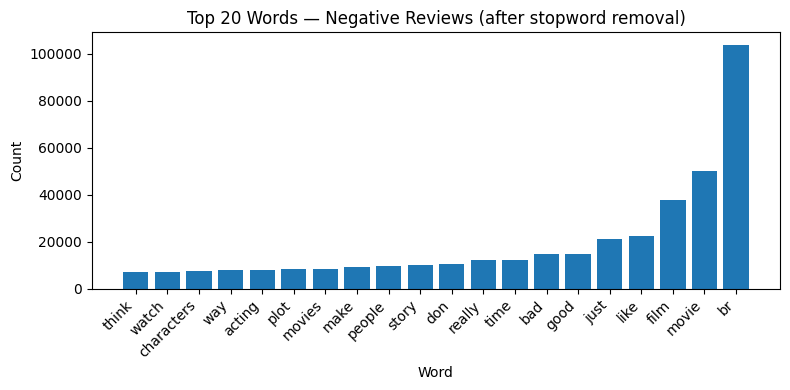

In [4]:
import re
from sklearn.feature_extraction.text import CountVectorizer

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

# Missing values
print("\nMissing values per column:")
print(df.isna().sum())

# Label distribution
label_counts = df["sentiment"].value_counts()
print("\nLabel distribution:")
print(label_counts)

plt.figure(figsize=(6,4))
label_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Review length features
df_eda = df.copy()
df_eda["char_len"] = df_eda["review"].astype(str).str.len()
df_eda["word_len"] = df_eda["review"].astype(str).str.split().str.len()

print("\nReview length (characters) summary:")
print(df_eda["char_len"].describe())
print("\nReview length (words) summary:")
print(df_eda["word_len"].describe())

# Length distribution (words) by sentiment
plt.figure(figsize=(7,4))
for s in ["positive", "negative"]:
    subset = df_eda[df_eda["sentiment"] == s]["word_len"]
    plt.hist(subset, bins=50, alpha=0.6, label=s)

plt.title("Review Length (Words) by Sentiment")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# Top words by sentiment (simple bag-of-words)
def top_words_for_sentiment(sentiment_label, top_n=20):
    texts = df_eda.loc[df_eda["sentiment"] == sentiment_label, "review"].astype(str).tolist()
    vect = CountVectorizer(stop_words="english", max_features=5000)
    Xw = vect.fit_transform(texts)
    counts = np.asarray(Xw.sum(axis=0)).ravel()
    vocab = np.array(vect.get_feature_names_out())
    top_idx = counts.argsort()[::-1][:top_n]
    return vocab[top_idx], counts[top_idx]

for s in ["positive", "negative"]:
    words, counts = top_words_for_sentiment(s, top_n=20)
    plt.figure(figsize=(8,4))
    plt.bar(words[::-1], counts[::-1])
    plt.title(f"Top 20 Words — {s.capitalize()} Reviews (after stopword removal)")
    plt.xlabel("Word")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 7. Data Preprocessing

Sentiment labels are encoded into numerical values for model training.

#### Label Encoding
Sentiment labels are converted into numerical form:
- positive → 1
- negative → 0
This conversion is necessary because machine learning algorithms require numerical inputs rather than text labels.

#### Why minimal preprocessing?
Since we are using sentence embeddings:
- Extensive text cleaning is not required
- Embedding models handle context, punctuation, and word order effectively

In [5]:
def basic_clean(text: str) -> str:
    """
    Minimal cleaning (IMDB contains HTML like <br />):
    - remove HTML tags
    - lowercase
    - normalize whitespace
    - keep punctuation (don't remove ! ? , .) because it helps sentiment
    - DO NOT remove stopwords (keeps 'not', 'never', etc.)
    """
    if pd.isna(text):
        return ""
    text = str(text)

    # Remove common HTML breaks and any remaining tags
    text = text.replace("<br /><br />", " ").replace("<br />", " ")
    text = re.sub(r"<[^>]+>", " ", text)

    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["review"].apply(basic_clean)

# Label: positive -> 1, negative -> 0
df["label"] = (df["sentiment"].str.lower().str.strip() == "positive").astype(int)

print("Text preprocessing complete!")
df.head(5)

Text preprocessing complete!


,review,sentiment,text,label
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production. the filming tec...,1
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"petter mattei's ""love in the time of money"" is...",1


# 8. Embeddings 

This section generates SentenceTransformer embeddings **one time** and saves them to disk.  
On future runs, it will **load instantly** from the saved `.npy` files.
- Avoids re-downloading / re-encoding every time  
- Lets you quickly try different classifiers (LogReg, SVM, etc.) using the same embeddings

In this step:
- Each movie review is passed through the SentenceTransformer
- Reviews are converted into numerical vectors
These vectors act as features for the classification model.

This approach allows the model to understand the meaning of sentences rather than just word frequency.

In [11]:
EMB_PATH = "imdb_embeddings.npy"
LAB_PATH = "imdb_labels.npy"
from sentence_transformers import SentenceTransformer
st_model = SentenceTransformer("all-MiniLM-L6-v2")

if os.path.exists(EMB_PATH) and os.path.exists(LAB_PATH):
    print("✓ Loading cached embeddings + labels...")
    X = np.load(EMB_PATH)
    y = np.load(LAB_PATH)
    print(f"  Loaded: {X.shape}, {y.shape}")
    

else:
    print("⏳ Generating embeddings (one-time). This may take a while on CPU...")
    from sentence_transformers import SentenceTransformer

    # Fast + strong baseline model for embeddings
    st_model = SentenceTransformer("all-MiniLM-L6-v2")

    texts = df["text"].astype(str).tolist()
    y = df["label"].values

    X = st_model.encode(
        texts,
        batch_size=64,        
        show_progress_bar=True,
        convert_to_numpy=True
    )

    np.save(EMB_PATH, X)
    np.save(LAB_PATH, y)
    print(f"✓ Saved embeddings to {EMB_PATH} and labels to {LAB_PATH}")
    print(f"  Shape: {X.shape}, {y.shape}")

✓ Loading cached embeddings + labels...
  Loaded: (50000, 384), (50000,)


## 9. Train Embedding-Based Classifier Using Cached Embeddings

Now we train a light classifier (Logistic Regression) on the saved embeddings.  
You can swap in other models (Linear SVM, XGBoost, etc.) without recomputing embeddings.

The dataset is split into:
- 80% Training data
- 20% Testing data

#### Purpose of splitting
- Training set is used to learn patterns
- Testing set is used to evaluate performance on unseen data
This prevents overfitting and ensures fair evaluation.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

emb_clf = LogisticRegression(max_iter=2000)
emb_clf.fit(X_train, y_train)

y_pred = emb_clf.predict(X_test)

print("\n" + "="*60)
print("EMBEDDING-BASED CLASSIFIER RESULTS")
print("="*60)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=["negative","positive"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Train: 40000 | Test: 10000

EMBEDDING-BASED CLASSIFIER RESULTS
Accuracy: 0.8265

              precision    recall  f1-score   support

    negative       0.83      0.83      0.83      5000
    positive       0.83      0.83      0.83      5000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000

Confusion Matrix:
[[4134  866]
 [ 869 4131]]


## 10. Saving the Trained Model

The trained model is saved using joblib.

#### Why save the model?
- Avoid retraining
- Enable reuse and deployment
- Support future experimentation
Model persistence is a standard practice in machine learning projects.

In [8]:
import joblib

joblib.dump(emb_clf, "sentiment_classifier_embeddings.joblib")
print("✓ Saved embedding classifier to sentiment_classifier_embeddings.joblib")

✓ Saved embedding classifier to sentiment_classifier_embeddings.joblib


## 11. Results and Observations

In [12]:
# Quick inference demo with embedding model
print("\n" + "="*60)
print("QUICK INFERENCE DEMO - EMBEDDING MODEL")
print("="*60)

sample_reviews = [
    "The food was amazing and the service was excellent.",
    "The food is not good.",
    "Yeah, great service… waited an hour for my food.",
    "Not bad at all, I actually enjoyed it.",
    "Worst experience. I will never come back.",
    "The movie was absolutely fantastic — I loved it!",
    "This was not good at all. Waste of time.",
    "Yeah, great... I fell asleep halfway through",
    "The acting was okay, but the story was boring.",
    "Not bad, actually pretty enjoyable.",
    "The movie was brilliant from start to finish.",
    "Outstanding performances and a very emotional story.",
    "I loved every minute of this film.",
    "One of the best movies I have seen in years.",
    "Excellent direction and powerful acting."
]

sample_emb = st_model.encode(sample_reviews, convert_to_numpy=True)
sample_pred = emb_clf.predict(sample_emb)

for r, p in zip(sample_reviews, sample_pred):
    label = "✓ POSITIVE" if p == 1 else "✗ NEGATIVE"
    print(f"{label:12} -> {r}")


QUICK INFERENCE DEMO - EMBEDDING MODEL
✓ POSITIVE   -> The food was amazing and the service was excellent.
✗ NEGATIVE   -> The food is not good.
✓ POSITIVE   -> Yeah, great service… waited an hour for my food.
✓ POSITIVE   -> Not bad at all, I actually enjoyed it.
✗ NEGATIVE   -> Worst experience. I will never come back.
✓ POSITIVE   -> The movie was absolutely fantastic — I loved it!
✗ NEGATIVE   -> This was not good at all. Waste of time.
✓ POSITIVE   -> Yeah, great... I fell asleep halfway through
✗ NEGATIVE   -> The acting was okay, but the story was boring.
✓ POSITIVE   -> Not bad, actually pretty enjoyable.
✓ POSITIVE   -> The movie was brilliant from start to finish.
✓ POSITIVE   -> Outstanding performances and a very emotional story.
✓ POSITIVE   -> I loved every minute of this film.
✓ POSITIVE   -> One of the best movies I have seen in years.
✓ POSITIVE   -> Excellent direction and powerful acting.
